#  Лабораторные работы
## Классификация с помощью решающих функций

Пять лабораторных работ с наращиванием сложности:
1. Геометрия линейных решающих функций и линейная разделимость.
2. Нахождение линейных решающих функций: градиентный спуск и алгоритм Хо–Кашьяпа.
3. Обобщённые решающие функции и спрямляющие отображения.
4. Метрики, расстояния, клетки Вороного и методы ближайших центров/соседей.
5. Кластеризация (k-means и др.) как основа прототипных методов и связь с линейными методами.

# Лабораторная работа 1
## Линейные решающие функции и линейная разделимость

**Цель:** закрепить понятия решающей функции, областей предпочтения, линейной решающей функции, линейной разделимости и выпуклых оболочек классов.

### Теоретические опорные пункты
- Пространство признаков, множество классов, области предпочтения $X_i$.
- Линейная решающая функция $d(x) = (w, x)$, разделяющая гиперплоскость $S = \{x : d(x)=0\}$.
- Связь линейной разделимости и непересекающихся выпуклых оболочек классов.

### Задание
1. Сгенерировать в 2D три варианта наборов данных: линейно разделимые, слабо пересекающиеся и явно линейно неразделимые классы.
2. Для линейно разделимого случая подобрать вектор весов $w, b$ для ЛРФ и визуализировать разделяющую прямую и области предпочтения.
3. Построить выпуклые оболочки классов и проверить, пересекаются ли они.
4. Для неразделимого случая продемонстрировать, что ни одной линейной гиперплоскостью нельзя корректно разделить классы без ошибок (на уровне эксперимента).
5. Сформулировать выводы о связи выпуклых оболочек и существования линейной разделяющей гиперплоскости.

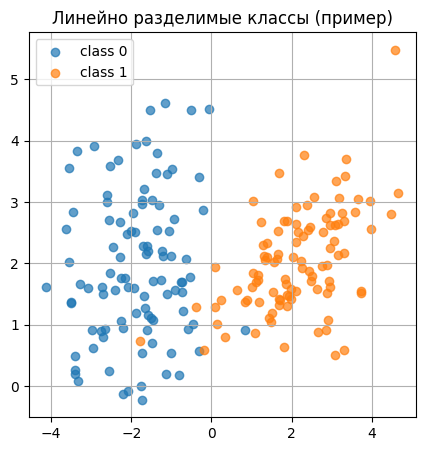

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import ConvexHull

np.random.seed(42)

def generate_linear_separable(n_samples=200, class_sep=2.0, random_state=42):
    X, y = # TODO
    return X, y

def generate_overlapping(n_samples=200, class_sep=0.8, noise=0.1, random_state=42):
    X, y = # TODO
    return X, y

def generate_nonlinear_moons(n_samples=200, noise=0.1, random_state=42):
    # TODO
    return X, y

def plot_dataset(X, y, title="Dataset"):
    plt.figure(figsize=(5, 5))
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"class {cls}", alpha=0.7)
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

# Пример: линейно разделимые классы
X_lin, y_lin = generate_linear_separable()
plot_dataset(X_lin, y_lin, title="Линейно разделимые классы (пример)")

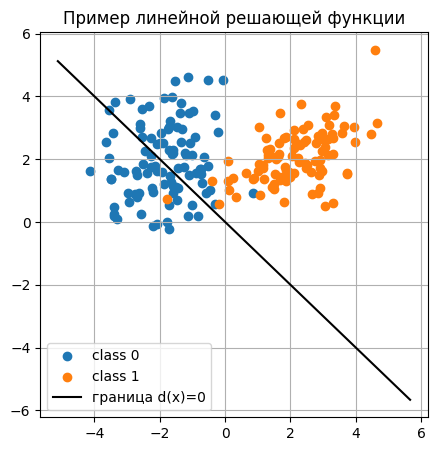

In [6]:
def plot_linear_decision_boundary(X, y, w, b, title="ЛРФ"):
    plt.figure(figsize=(5, 5))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    xs = np.linspace(x_min, x_max, 200)
    if abs(w[0]) > 1e-8:
        ys = -(w[0] * xs + b) / w[0]
    else:
        ys = np.zeros_like(xs)
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"class {cls}")
    plt.plot(xs, ys, 'k-', label="граница d(x)=0")
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

# TODO: подобрать пример вектора w, b для линейно разделимого случая
w_example = np.array([1.0, 1.0])
b_example = 0.0
plot_linear_decision_boundary(X_lin, y_lin, w_example, b_example,
                             title="Пример линейной решающей функции")

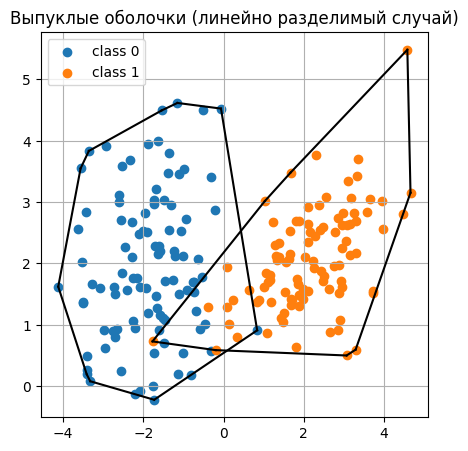

In [7]:
def plot_convex_hulls(X, y, title="Выпуклые оболочки"):
    plt.figure(figsize=(5, 5))
    for cls in np.unique(y):
        Xc = X[y == cls]
        plt.scatter(Xc[:, 0], Xc[:, 1], label=f"class {cls}")
        if len(Xc) >= 3:
            hull = ConvexHull(Xc)
            for simplex in hull.simplices:
                plt.plot(Xc[simplex, 0], Xc[simplex, 1], 'k-')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_convex_hulls(X_lin, y_lin, title="Выпуклые оболочки (линейно разделимый случай)")

# Лабораторная работа 2
## Нахождение ЛРФ: градиентный спуск и алгоритм Хо–Кашьяпа

**Цель:** реализовать два подхода к поиску линейной решающей функции на двухклассовой выборке и сравнить их поведение.

### Теоретические опорные пункты
- Унифицированные векторы $x'_i$ и условие $(w, x'_i) > 0$ для всех $i$.
- Функция критерия $F(w)$ и метод градиентного спуска.
- Переопределённая задача и идея алгоритма Хо–Кашьяпа.

In [ ]:
def generate_2class_linear(n_samples=200, class_sep=2.0, random_state=0):
    X, y = # TODO
    y_signed = np.where(y == 0, -1, 1)
    return X, y_signed

X2, y2 = generate_2class_linear()
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=0)

def make_unified_vectors(X, y):
    return X * y[:, None]

X2_train_unif = make_unified_vectors(X2_train, y2_train)

In [ ]:
def F_criterion(w, X_unified):
   # TODO
     

def grad_F(w, X_unified):
    # TODO


def gradient_descent_LDF(X_unified, max_iter=1000, lr=0.01, tol=1e-6):
    # TODO

w_gd, hist_gd = gradient_descent_LDF(X2_train_unif, max_iter=500, lr=0.01)
w_gd, hist_gd[:5]

In [ ]:
def ho_kashyap(X_unified, max_iter=1000, lr=0.1, eps=1e-3):
    # TODO

w_hk, y_hk = ho_kashyap(X2_train_unif, max_iter=1000, lr=0.1)
w_hk

array([ 1.2744661 , -0.16052651])

# Лабораторная работа 3
## Обобщённые решающие функции и спрямляющие отображения

**Цель:** реализовать обобщённую решающую функцию через явное нелинейное отображение признаков и показать, как нелинейно неразделимые классы становятся линейно разделимыми в расширенном пространстве.

### Теоретические опорные пункты
- Обобщённая решающая функция $d(x) = \sum w_i f_i(x)$.
- Спрямляющее отображение $\varphi: \mathbb{R}^n \to \mathbb{R}^l$.
- Мономиальные функции как пример набора признаков.

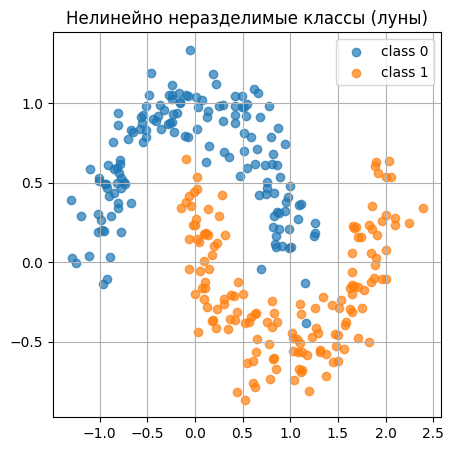

0.8566666666666667

In [ ]:
from sklearn.linear_model import LogisticRegression

X_moons, y_moons = generate_nonlinear_moons(n_samples=300, noise=0.15, random_state=0)
plot_dataset(X_moons, y_moons, title="Нелинейно неразделимые классы (луны)")

def fit_linear_classifier(X, y):
    # TODO

clf_linear = fit_linear_classifier(X_moons, y_moons)
acc_linear = accuracy_score(y_moons, clf_linear.predict(X_moons))
acc_linear

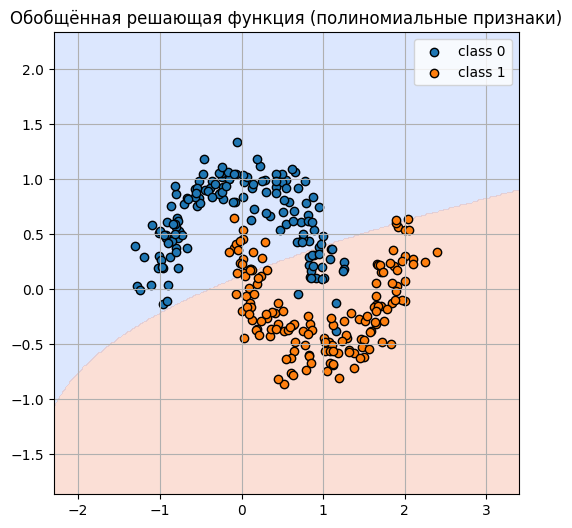

In [12]:
def plot_decision_boundary_feature_map(X, y, clf, phi, title="ОРФ"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(phi(grid))
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5], cmap="coolwarm")
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"class {cls}", edgecolor="k")
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_decision_boundary_feature_map(
    X_moons, y_moons, clf_phi, phi_poly2,
    title="Обобщённая решающая функция (полиномиальные признаки)"
)

# Лабораторная работа 4
## Метрики, расстояния и клетки Вороного

**Цель:** исследовать влияние выбора метрики и стандартизации признаков на классификацию по ближайшему центру и структуру клеток Вороного.

### Теоретические опорные пункты
- Метрики Евклида, Манхэттена, Чебышёва.
- Расстояние от вектора до центра класса и правило классификации по центрам.
- Клетки Вороного.
- Стандартизация признаков (z-score, min–max).

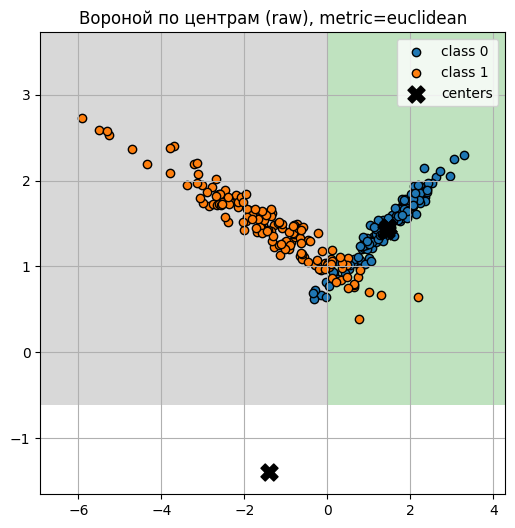

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Xc, yc = generate_linear_separable(n_samples=300, class_sep=1.5, random_state=1)

def compute_class_centers(X, y):
   # TODO

def predict_nearest_center(X, centers, metric="euclidean"):
    # TODO
    return np.array(preds)

def plot_voronoi_like(X, y, centers, metric="euclidean", title="Клетки Вороного"):
    # TODO

centers_raw = compute_class_centers(Xc, yc)
plot_voronoi_like(Xc, yc, centers_raw, metric="euclidean", title="Вороной по центрам (raw)")

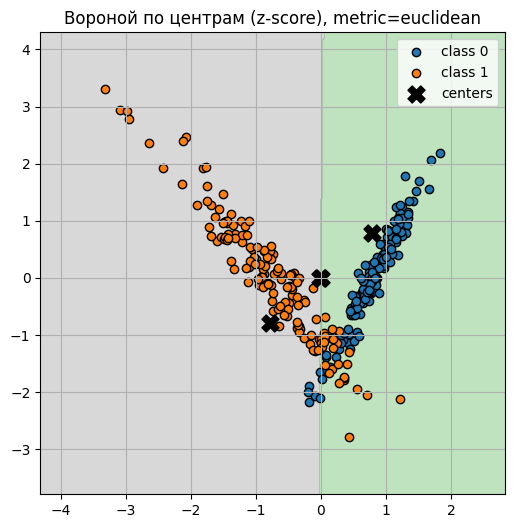

In [14]:
scaler_z = StandardScaler()
Xc_z = scaler_z.fit_transform(Xc)
centers_z = compute_class_centers(Xc_z, yc)
plot_voronoi_like(Xc_z, yc, centers_z, metric="euclidean", title="Вороной по центрам (z-score)")

# Лабораторная работа 5
## Кластеризация и прототипные методы (k-means, maximin) и связь с классификацией

**Цель:** реализовать k-means и один алгоритм расстановки центров (например, maximin), использовать их для прототипного представления классов и связать с методами ближайшего соседа/центра.

### Теоретические опорные пункты
- Математическая постановка задачи кластеризации и критерий внутригруппового разброса.
- Алгоритм k-внутригрупповых средних (k-means).
- Алгоритмы расстановки центров (maximin, простейшая расстановка).
- Прототипы кластеров как опорные точки для классификации.

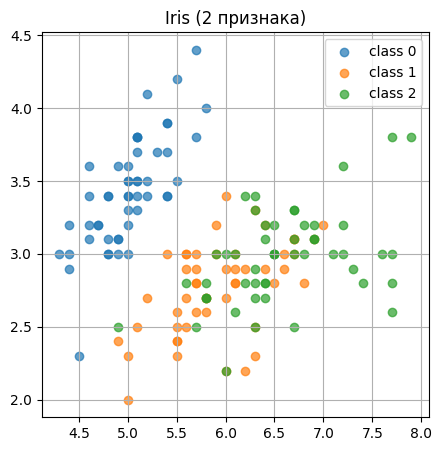

array([[5.77358491, 2.69245283],
       [6.81276596, 3.07446809],
       [5.006     , 3.428     ]])

In [15]:
from sklearn.cluster import KMeans

iris = datasets.load_iris()
X_iris = iris.data[:, :2]
y_iris = iris.target

plot_dataset(X_iris, y_iris, title="Iris (2 признака)")

def run_kmeans(X, n_clusters, random_state=0):
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_
    return km, labels, centers

km_iris, labels_iris, centers_iris = run_kmeans(X_iris, n_clusters=3)
centers_iris

In [ ]:
import numpy as np

def maximin_centers(X, dist_metric="euclidean", max_centers=5):
    X = np.asarray(X)
    
    N = X.shape[0]

     
    centers_idx = [0]    

    while len(centers_idx) < max_centers:
        dists = []
        for i in range(N):
            if i in centers_idx:
                dists.append(0.0)
                continue
            x = X[i]
            d_min = np.inf
            for idx in centers_idx:
                c = X[idx]
                if dist_metric == "euclidean":
                    d = np.linalg.norm(x - c)
                else:
                    # здесь можно добавить другие метрики,
                    
                    d = np.linalg.norm(x - c)
                if d < d_min:
                    d_min = d
            dists.append(d_min)
 
        farthest_idx = np.argmax(dists)
        if dists[farthest_idx] == 0:
            break
        centers_idx.append(farthest_idx)

    centers = X[centers_idx]
    return centers_idx, centers


idx_mm, centers_mm = maximin_centers(X_iris, max_centers=5)
idx_mm, centers_mm

([0, np.int64(131), np.int64(108), np.int64(60), np.int64(15)],
 array([[5.1, 3.5],
        [7.9, 3.8],
        [6.7, 2.5],
        [5. , 2. ],
        [5.7, 4.4]]))

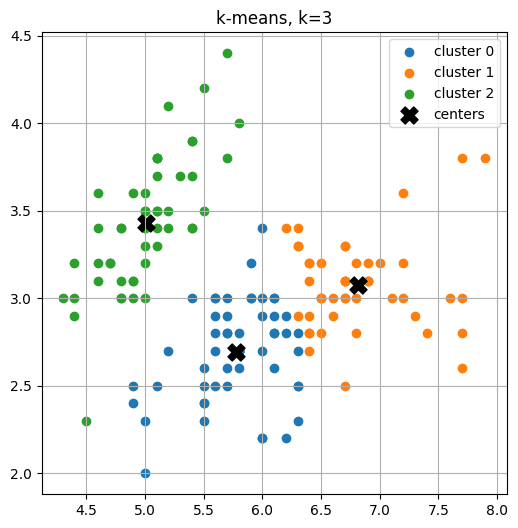

In [20]:
def plot_clusters_with_centers(X, labels, centers, title="Clusters"):
    plt.figure(figsize=(6, 6))
    for lab in np.unique(labels):
        plt.scatter(X[labels == lab, 0], X[labels == lab, 1], label=f"cluster {lab}")
    plt.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=150, label="centers")
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_clusters_with_centers(X_iris, labels_iris, centers_iris, title="k-means, k=3")